In [ ]:
!pip install pandas
!pip install nltk
!pip install stopwords

In [ ]:
#Import Package
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC
from ipywidgets import widgets
from IPython.display import display


In [ ]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Read the data
path="/content/drive/MyDrive/shiplu's dataset/Youtube01-Psy.csv"
Psy = pd.read_csv(path)
path1="/content/drive/MyDrive/shiplu's dataset/Youtube02-KatyPerry.csv"
Katy = pd.read_csv(path1)
path2="/content/drive/MyDrive/shiplu's dataset/Youtube03-LMFAO.csv"
Eminem = pd.read_csv(path2)
path3="/content/drive/MyDrive/shiplu's dataset/Youtube04-Eminem.csv"
Shakira = pd.read_csv(path3)
path4="/content/drive/MyDrive/shiplu's dataset/Youtube05-Shakira.csv"
LMFAO = pd.read_csv(path4)


#path5="/content/drive/MyDrive/spam.csv"
#path5 = "/content/drive/MyDrive/spam.csv"
#po = pd.read_csv(path5, encoding='ISO-8859-1')
# Combine the data
df = pd.concat([Shakira, Eminem, Katy, Psy, LMFAO])
df.drop('DATE', axis=1, inplace=True)


In [ ]:
df.shape


(1956, 4)

In [ ]:
df.head()

,COMMENT_ID,AUTHOR,CONTENT,CLASS
0,z12rwfnyyrbsefonb232i5ehdxzkjzjs2,Lisa Wellas,+447935454150 lovely girl talk to me xxx﻿,1
1,z130wpnwwnyuetxcn23xf5k5ynmkdpjrj04,jason graham,I always end up coming back to this song<br />﻿,0
2,z13vsfqirtavjvu0t22ezrgzyorwxhpf3,Ajkal Khan,"my sister just received over 6,500 new <a rel=...",1
3,z12wjzc4eprnvja4304cgbbizuved35wxcs,Dakota Taylor,Cool﻿,0
4,z13xjfr42z3uxdz2223gx5rrzs3dt5hna,Jihad Naser,Hello I&#39;am from Palastine﻿,1


1    1005
0     951
Name: CLASS, dtype: int64


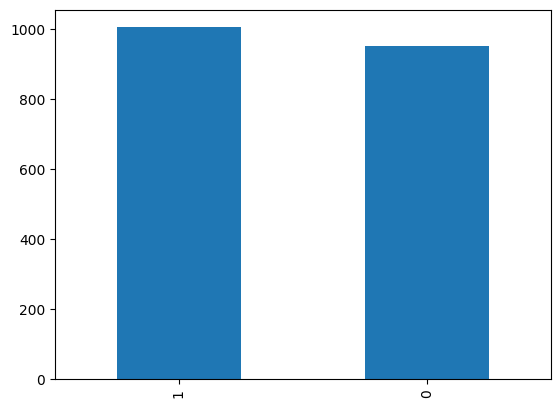

In [ ]:
df['CLASS'].value_counts().plot(kind='bar')
classes = df['CLASS']
print(classes.value_counts())


In [ ]:
# Text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
    words = word_tokenize(text)
    words = [word.lower() for word in words if word.isalpha()]
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['CONTENT'] = df['CONTENT'].apply(preprocess_text)

print(df['CONTENT'][:10])

0                                     lovely girl talk
1                       always end coming back song br
2    sister received new nofollow http active youtu...
3                                                     
4                                                hello
5           wow video almost billion view know popular
6      go check rapping video called four wheel please
7                                               almost
8                                         aslamu lykum
9                     eminem idol people españa mexico
Name: CONTENT, dtype: object


In [ ]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X = tfidf_vectorizer.fit_transform(df['CONTENT']).toarray()
y = df['CLASS']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=1)

In [ ]:
# Define classifiers
svm_clf = SVC(kernel='linear', probability=True)
ada_clf = AdaBoostClassifier()
rf_clf = RandomForestClassifier()

In [ ]:
# Soft Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('svm', svm_clf),
    ('ada', ada_clf),
    ('rf', rf_clf)
], voting='soft')

In [ ]:
# Train the voting classifier
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('svm', SVC(kernel='linear', probability=True)),
                             ('ada', AdaBoostClassifier()),
                             ('rf', RandomForestClassifier())],
                 voting='soft')

In [ ]:
# Function to check message
def check_message(btn):
    input_text = text_input.value
    input_text_processed = preprocess_text(input_text)
    input_vector = tfidf_vectorizer.transform([input_text_processed]).toarray()

    prediction = voting_clf.predict(input_vector)[0]

    print("Message:", input_text)
    print("Prediction:", "SPAM" if prediction == 1 else "HAM")

In [ ]:
# Create text input widget for message input
text_input = widgets.Textarea(
    value='',
    placeholder='Enter your message here',
    description='Message:',
    disabled=False
)

In [ ]:
# Create button to check the message
check_button = widgets.Button(description="Check")
check_button.on_click(check_message)

In [ ]:
# Display widgets
display(text_input, check_button)

Textarea(value='', description='Message:', placeholder='Enter your message here')

Button(description='Check', style=ButtonStyle())